# **Logistic Regression III**

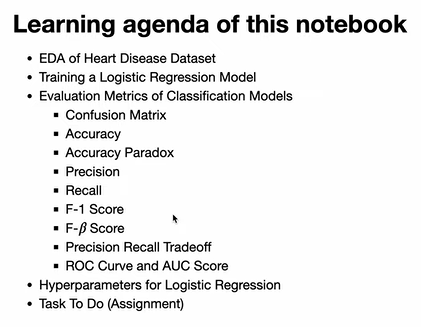

In [1]:
import numpy as np # np is short for numpy
import pandas as pd # pandas is so commonly used, it's shortened to pd
import matplotlib.pyplot as plt
import seaborn as sns # seaborn gets shortened to sns

%matplotlib inline

from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import RocCurveDisplay


In [2]:
!pip install ucimlrepo

In [3]:
from ucimlrepo import fetch_ucirepo
import pandas as pd

# Fetch the dataset
heart_disease = fetch_ucirepo(id=45)

# Create DataFrame
df = pd.concat([heart_disease.data.features, heart_disease.data.targets], axis=1)

df


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45,1,1,110,264,0,0,132,0,1.2,2,0.0,7.0,1
299,68,1,4,144,193,1,0,141,0,3.4,2,2.0,7.0,2
300,57,1,4,130,131,0,0,115,1,1.2,2,1.0,7.0,3
301,57,0,2,130,236,0,2,174,0,0.0,2,1.0,3.0,1


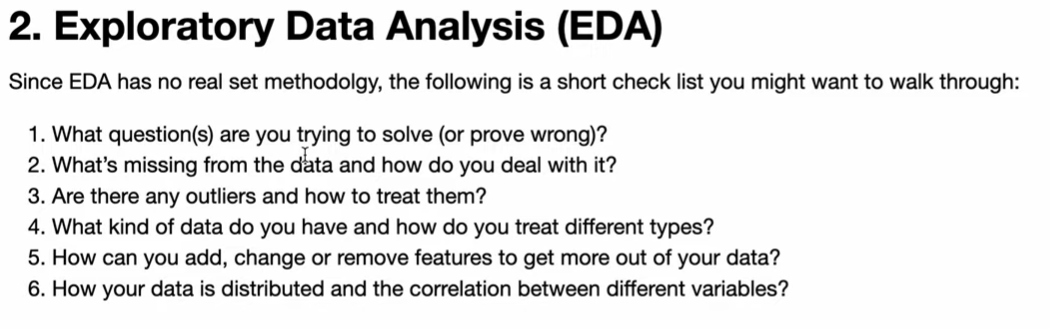

In [4]:
df['num'].nunique()

5

In [5]:
df['num'].unique()

array([0, 2, 1, 3, 4])

In [6]:
heart_disease.data.targets

,num
0,0
1,2
2,1
3,0
4,0
...,...
298,1
299,2
300,3
301,1


In [7]:
df['num'] = df['num'].apply(lambda x: 0 if x == 0 else 1)


In [8]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45,1,1,110,264,0,0,132,0,1.2,2,0.0,7.0,1
299,68,1,4,144,193,1,0,141,0,3.4,2,2.0,7.0,1
300,57,1,4,130,131,0,0,115,1,1.2,2,1.0,7.0,1
301,57,0,2,130,236,0,2,174,0,0.0,2,1.0,3.0,1


In [9]:
df.isna().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [10]:
df['thal'].unique()

array([ 6.,  3.,  7., nan])

In [11]:
df['thal'] = df['thal'].fillna(df['thal'].mode()[0])

In [12]:
df['thal'].unique()

array([6., 3., 7.])

Male: 1

Female: 0

In [13]:
df['sex'].value_counts()

,count
sex,
1,206
0,97


chest pin

In [14]:
df['ca'].value_counts()

,count
ca,
0.0,176
1.0,65
2.0,38
3.0,20


In [15]:
df['ca'].isna().sum()

np.int64(4)

In [16]:
df['ca'] = df['ca'].fillna(df['ca'].mode()[0])
df['ca'].isna().sum()

np.int64(0)

In [17]:
df['num'].value_counts()

,count
num,
0,164
1,139


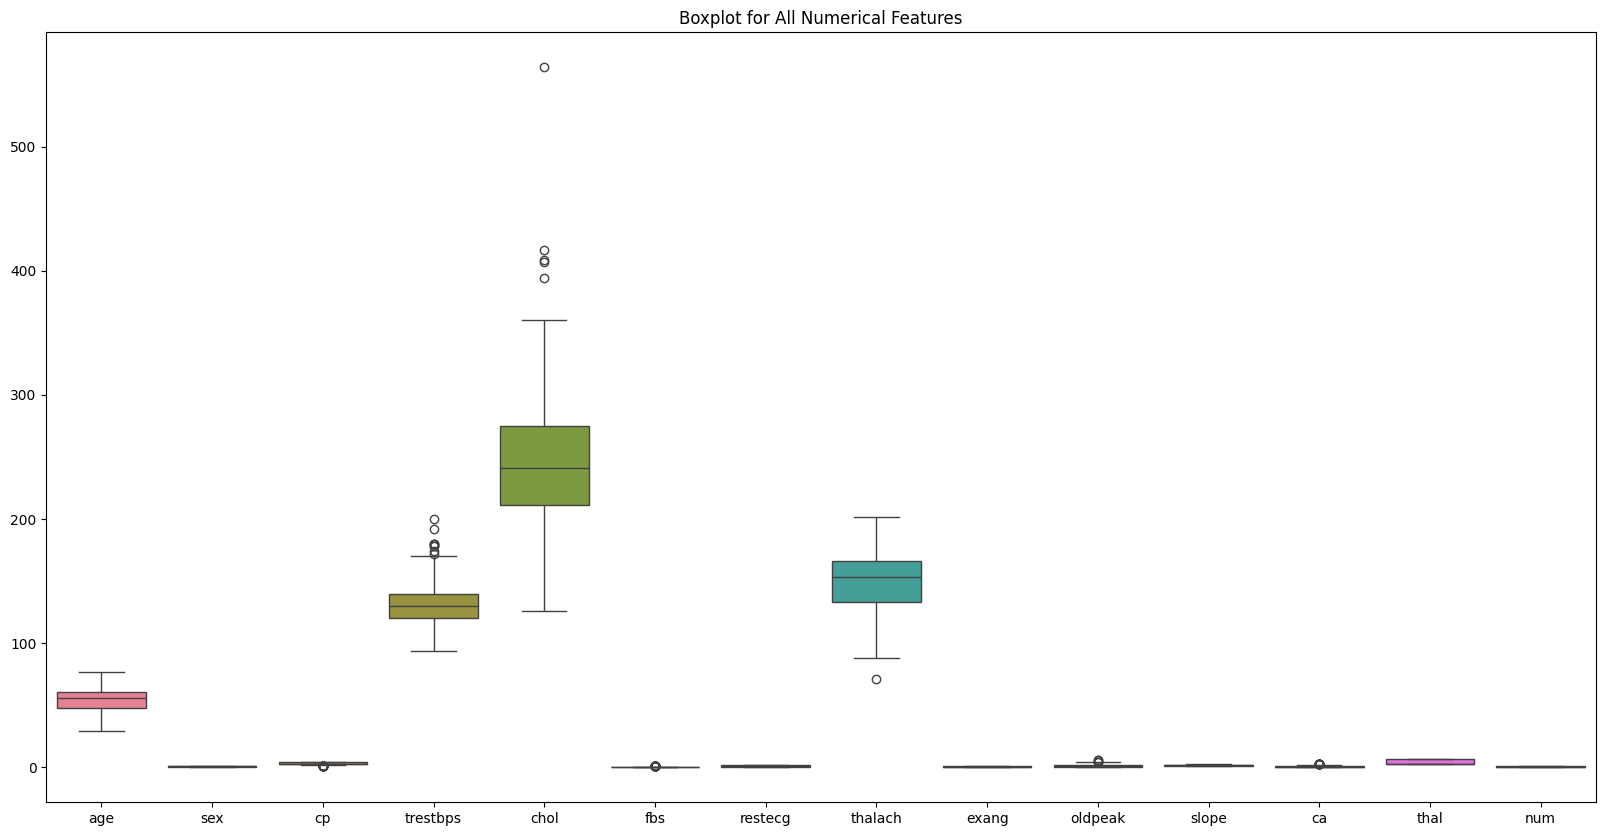

In [18]:

plt.figure(figsize=(20, 10))
sns.boxplot(data=df)
plt.title("Boxplot for All Numerical Features")
plt.show()


<Axes: xlabel='age', ylabel='thalach'>

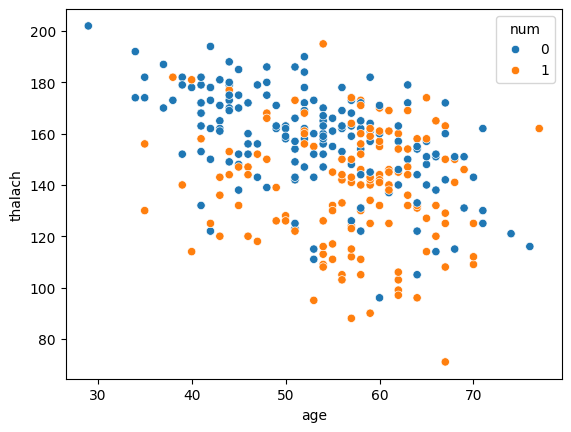

In [19]:
sns.scatterplot(data=df, x='age',y='thalach', hue='num')

<Axes: >

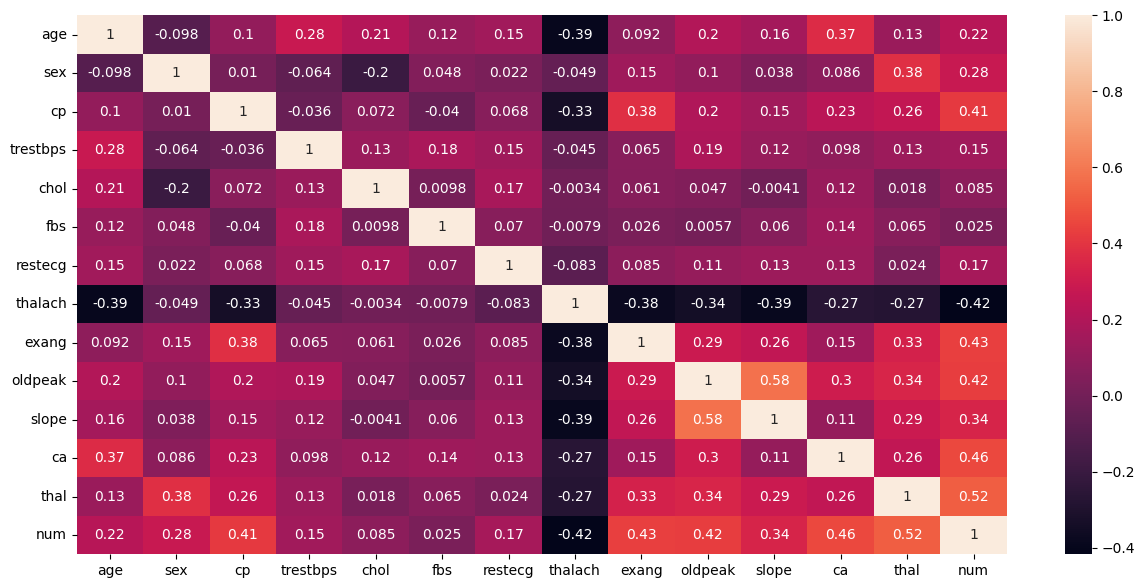

In [20]:
plt.figure(figsize=(15,7))
sns.heatmap(df.corr(),annot=True)

**Model Traning:**

In [21]:
from sklearn.model_selection import train_test_split
X =df.drop('num',axis=1)
y = df['num']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)
len(X_train),len(X_test),len(y_train),len(y_test)

(242, 61, 242, 61)

In [22]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
ss.fit(X_train)

scaled_X_train = ss.transform(X_train)
scaled_X_test = ss.transform(X_test)
len(scaled_X_train),len(scaled_X_test)

(242, 61)

In [23]:
lr = LogisticRegression()
lr.fit(scaled_X_train,y_train)

LogisticRegression()

In [24]:
lr.coef_

array([[ 0.06638017,  0.71117148,  0.50482228,  0.32361649,  0.43553816,
        -0.26991207,  0.14130824, -0.2909887 ,  0.44170834,  0.33887996,
         0.434229  ,  1.14697432,  0.47720696]])

In [25]:
# bias
lr.intercept_

array([-0.2045619])

In [26]:
prob = lr.predict_proba(scaled_X_test)
prob


array([[0.27721767, 0.72278233],
       [0.18827362, 0.81172638],
       [0.22771789, 0.77228211],
       [0.48935794, 0.51064206],
       [0.37282473, 0.62717527],
       [0.13430871, 0.86569129],
       [0.04596103, 0.95403897],
       [0.00604359, 0.99395641],
       [0.71037236, 0.28962764],
       [0.46411729, 0.53588271],
       [0.95160819, 0.04839181],
       [0.98316949, 0.01683051],
       [0.2200984 , 0.7799016 ],
       [0.01542519, 0.98457481],
       [0.00510047, 0.99489953],
       [0.9293875 , 0.0706125 ],
       [0.96858822, 0.03141178],
       [0.34506237, 0.65493763],
       [0.00173938, 0.99826062],
       [0.91362877, 0.08637123],
       [0.19277299, 0.80722701],
       [0.94067249, 0.05932751],
       [0.00529859, 0.99470141],
       [0.9512936 , 0.0487064 ],
       [0.00589927, 0.99410073],
       [0.97518605, 0.02481395],
       [0.68049077, 0.31950923],
       [0.1378484 , 0.8621516 ],
       [0.14898082, 0.85101918],
       [0.49200924, 0.50799076],
       [0.

In [27]:
y_prob= prob[:,1]
y_prob

array([0.72278233, 0.81172638, 0.77228211, 0.51064206, 0.62717527,
       0.86569129, 0.95403897, 0.99395641, 0.28962764, 0.53588271,
       0.04839181, 0.01683051, 0.7799016 , 0.98457481, 0.99489953,
       0.0706125 , 0.03141178, 0.65493763, 0.99826062, 0.08637123,
       0.80722701, 0.05932751, 0.99470141, 0.0487064 , 0.99410073,
       0.02481395, 0.31950923, 0.8621516 , 0.85101918, 0.50799076,
       0.17942728, 0.63309508, 0.01544292, 0.40105584, 0.22447271,
       0.66334287, 0.97355878, 0.48408034, 0.98911291, 0.17993164,
       0.9811172 , 0.31821684, 0.8672472 , 0.05286828, 0.21257042,
       0.93246158, 0.0799378 , 0.12042907, 0.80936409, 0.81204118,
       0.21513325, 0.02246879, 0.01781547, 0.1878993 , 0.93563129,
       0.18659899, 0.03612217, 0.96882874, 0.89291792, 0.92022864,
       0.13599678])

In [28]:
output=np.array([1.0 if p > 0.5 else 0 for p in y_prob])
output


array([1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 0., 0., 1., 1., 1., 0., 0.,
       1., 1., 0., 1., 0., 1., 0., 1., 0., 0., 1., 1., 1., 0., 1., 0., 0.,
       0., 1., 1., 0., 1., 0., 1., 0., 1., 0., 0., 1., 0., 0., 1., 1., 0.,
       0., 0., 0., 1., 0., 0., 1., 1., 1., 0.])

In [29]:
y_pred = lr.predict(scaled_X_test)
y_pred

array([1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0,
       1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0])

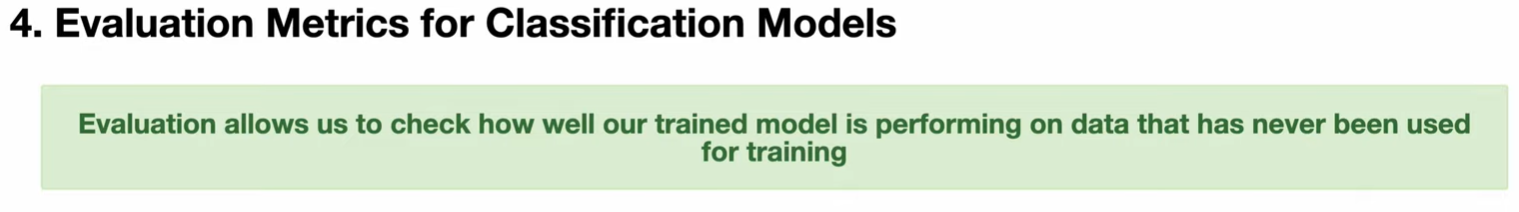

In [30]:
y_test.values

array([0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0,
       1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1])

In [31]:
y_pred

array([1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0,
       1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0])

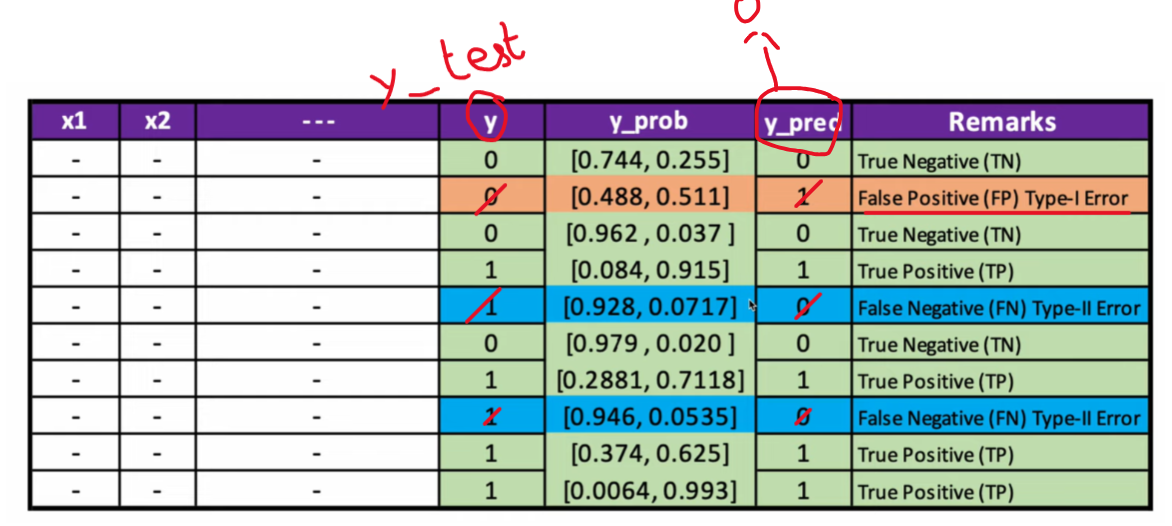

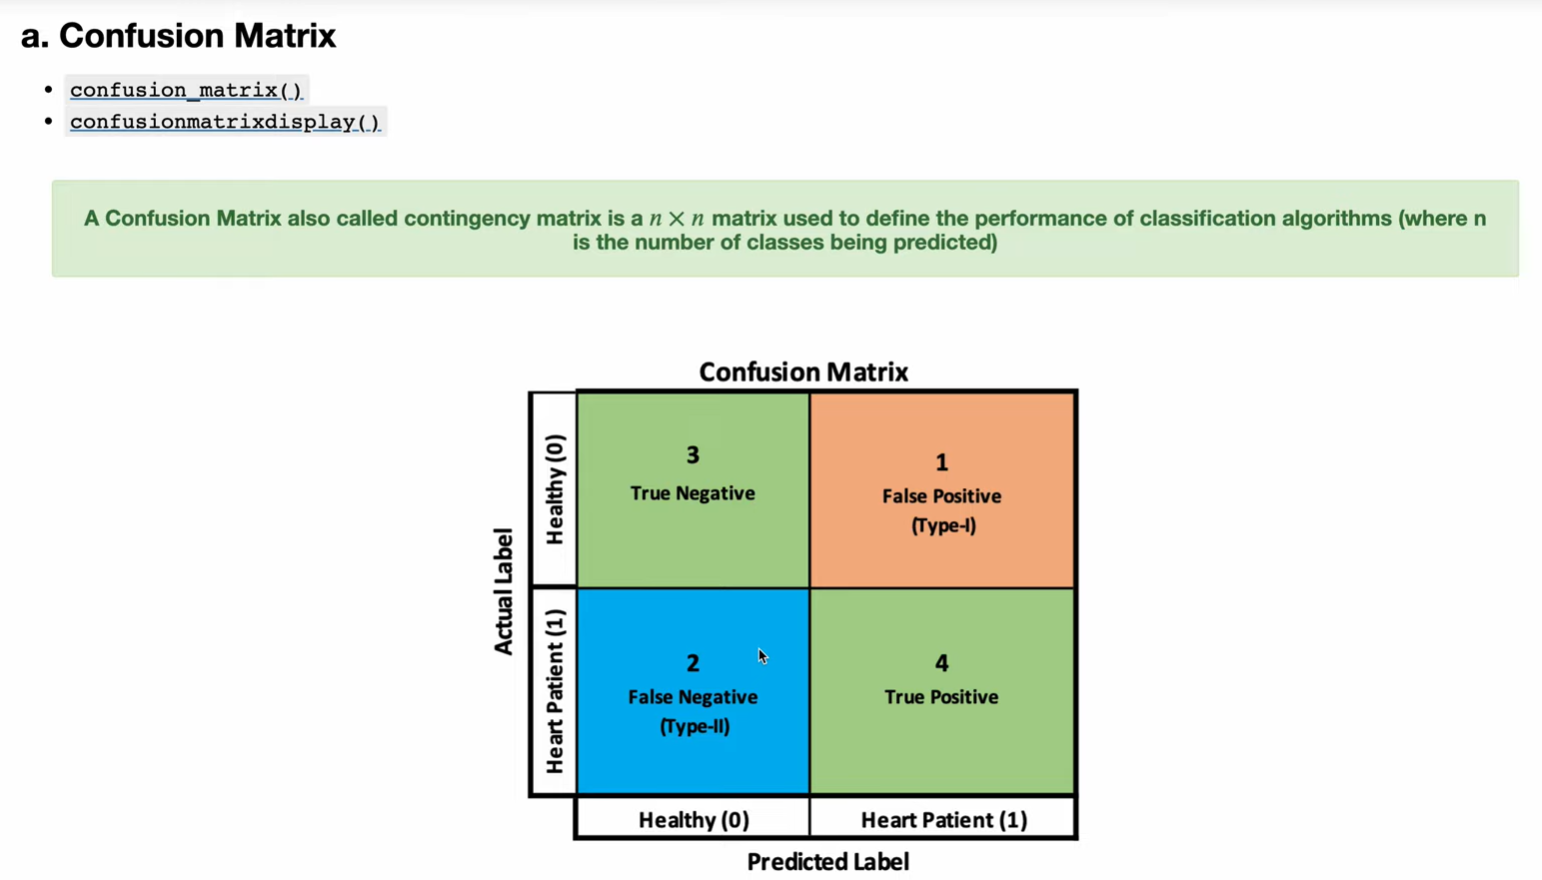

In [32]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test,y_pred=y_pred)

array([[25,  4],
       [ 3, 29]])

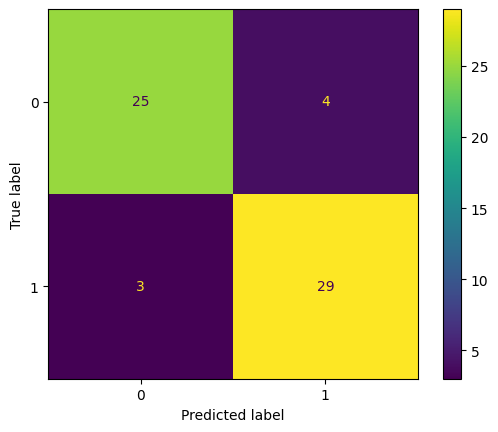

In [33]:
from sklearn.metrics import ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix(y_test,y_pred=y_pred))
disp.plot()


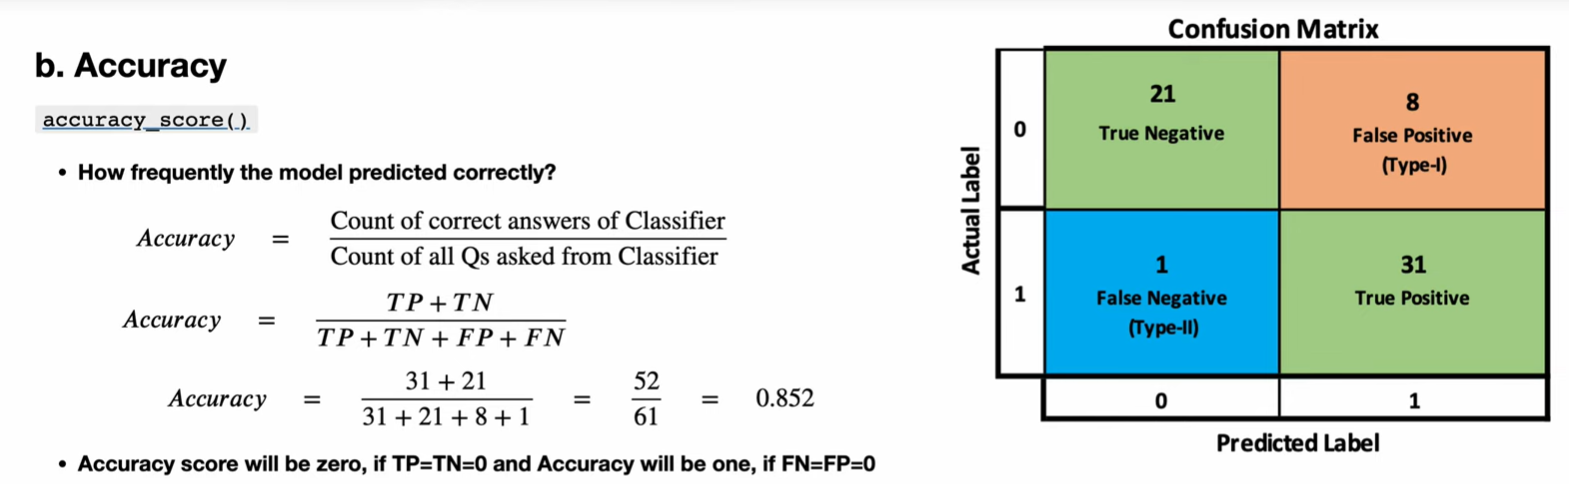

In [34]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.8852459016393442

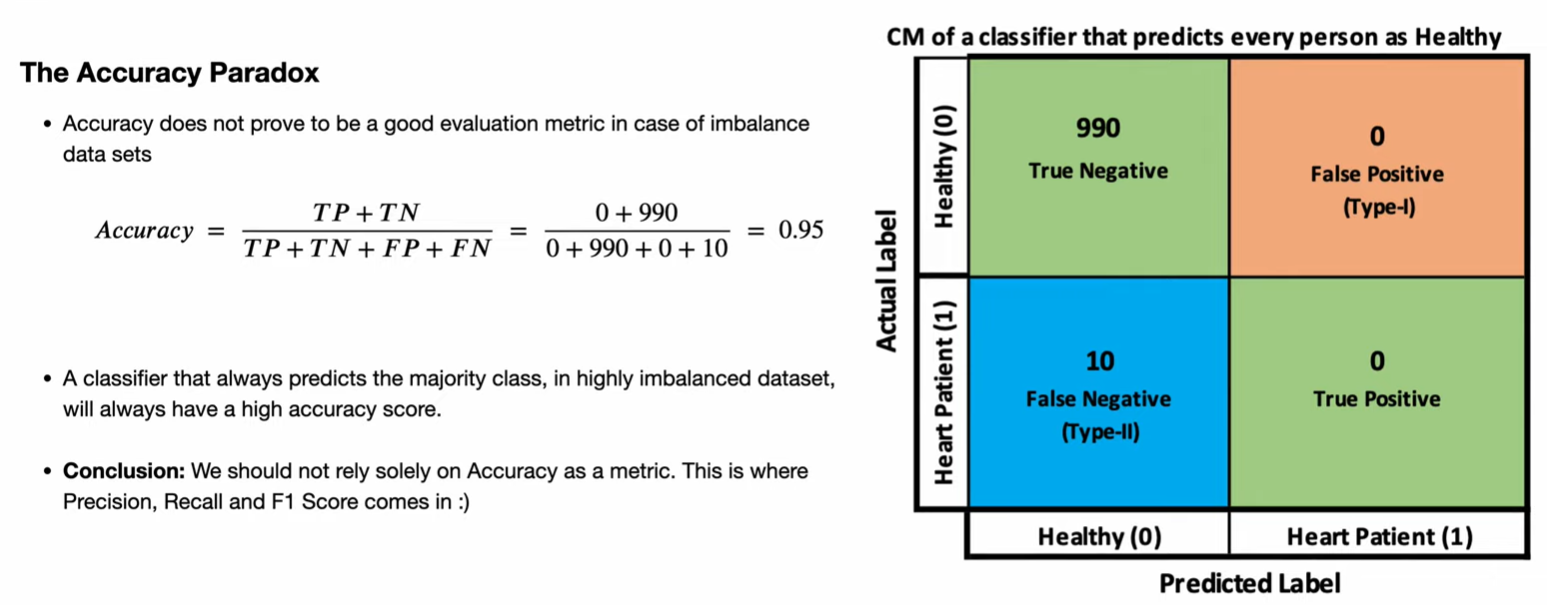

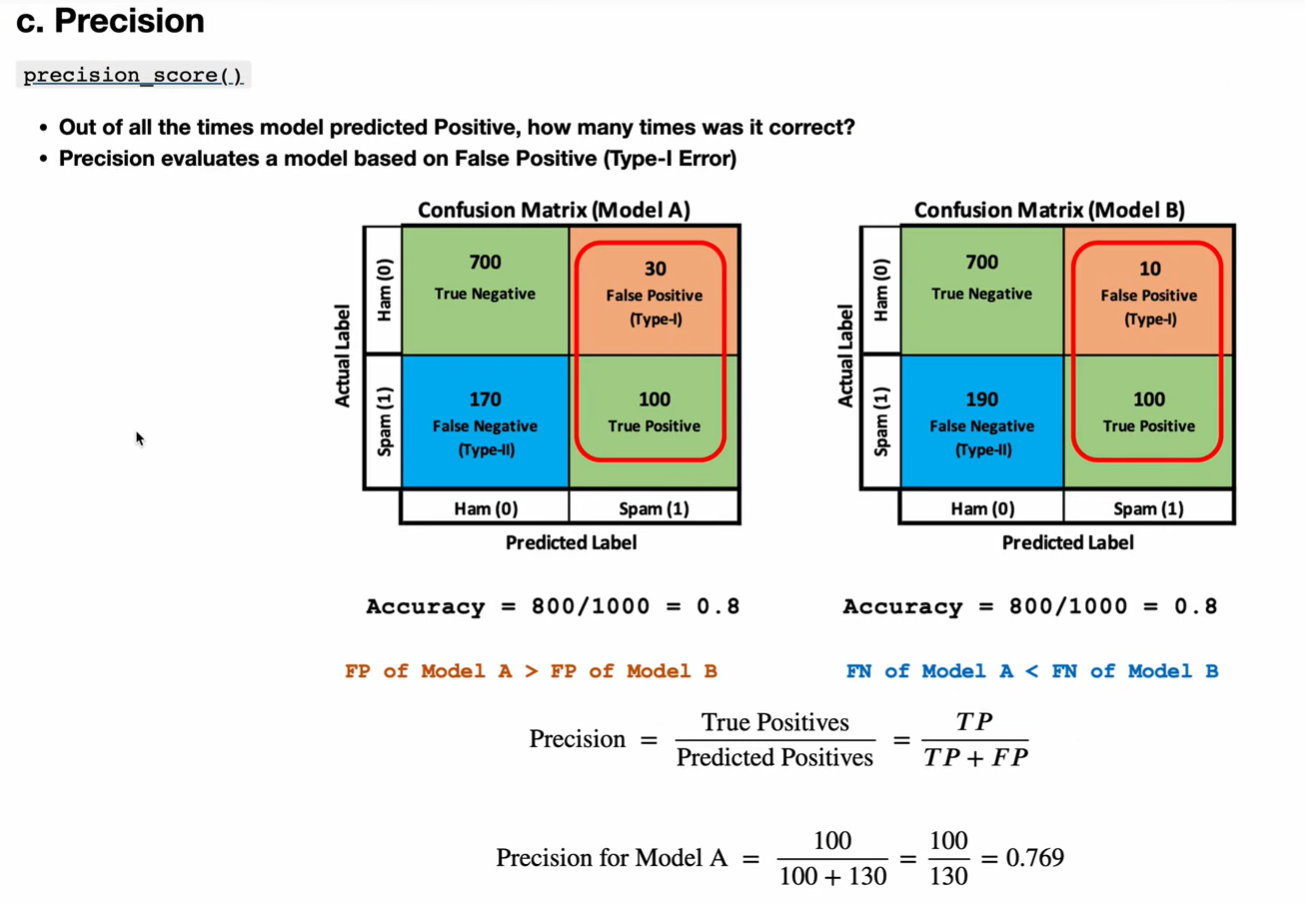

In [35]:
from sklearn.metrics import precision_score
precision_score(y_test, y_pred)

0.8787878787878788

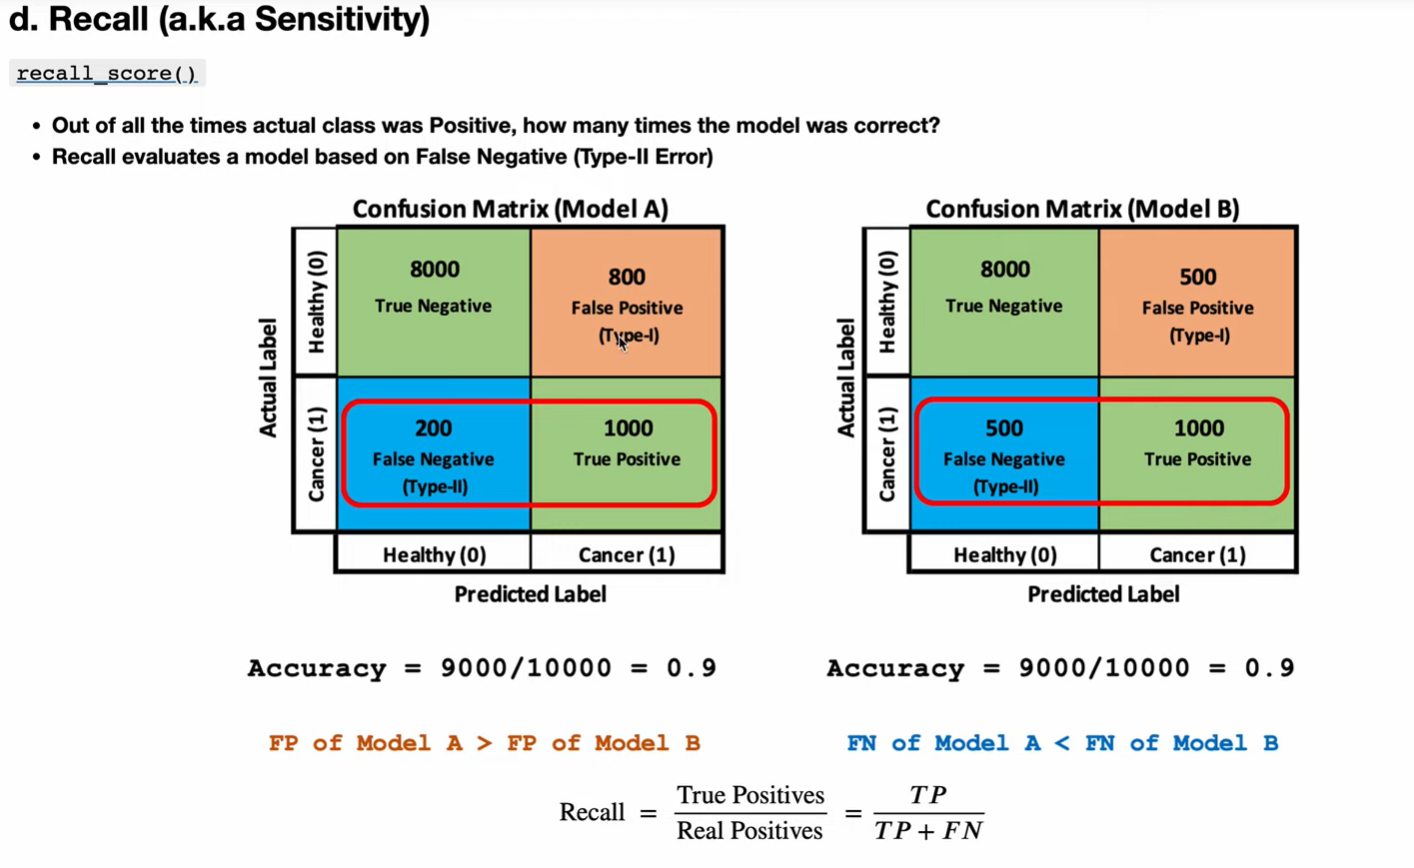

In [36]:
from sklearn.metrics import recall_score
recall_score(y_test, y_pred)

0.90625

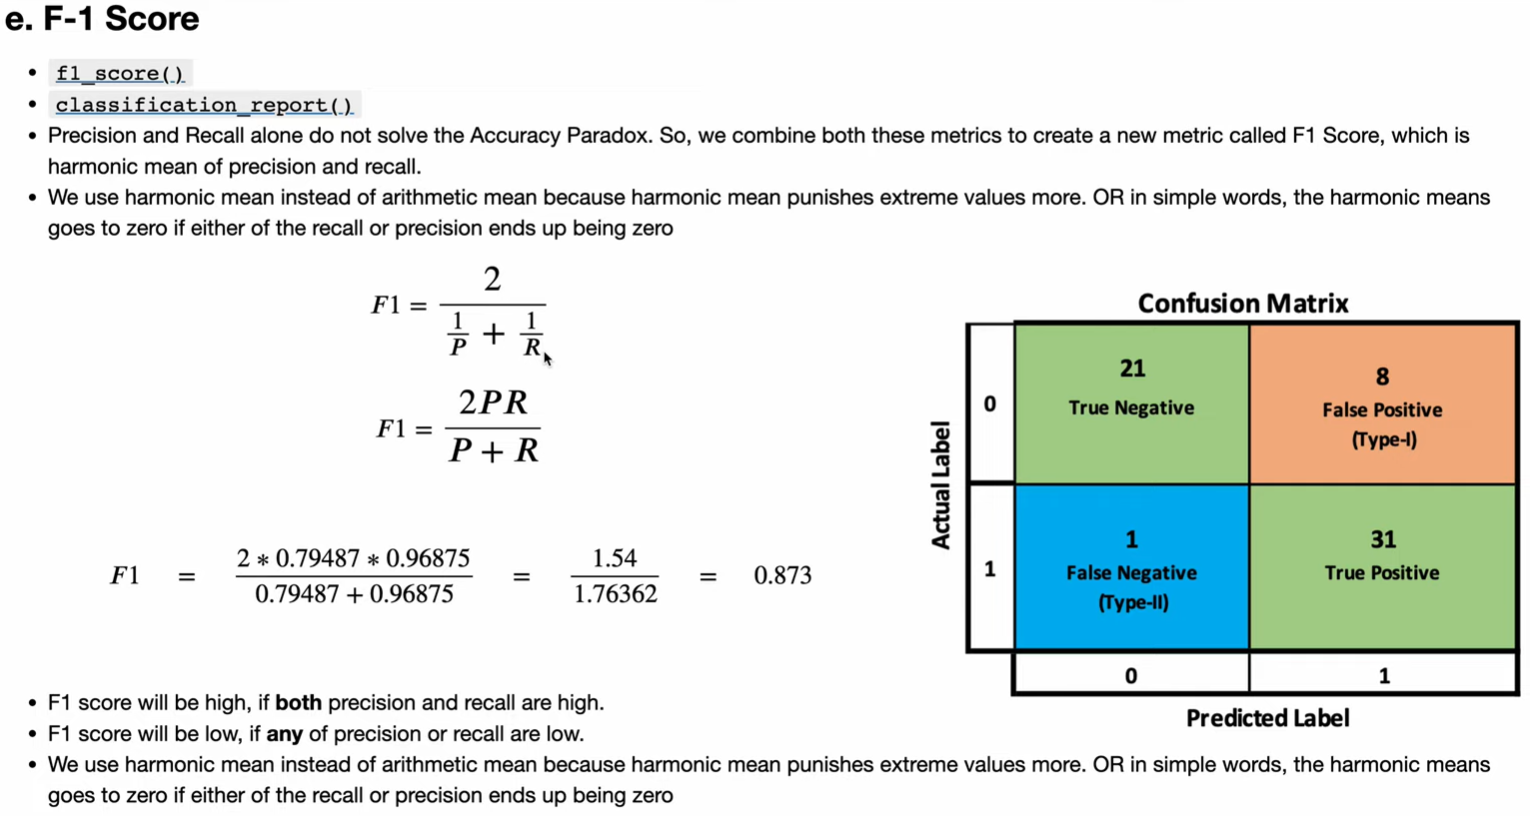

In [37]:
from sklearn.metrics import f1_score
f1_score(y_test, y_pred)

0.8923076923076924

In [39]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.86      0.88        29
           1       0.88      0.91      0.89        32

    accuracy                           0.89        61
   macro avg       0.89      0.88      0.88        61
weighted avg       0.89      0.89      0.89        61



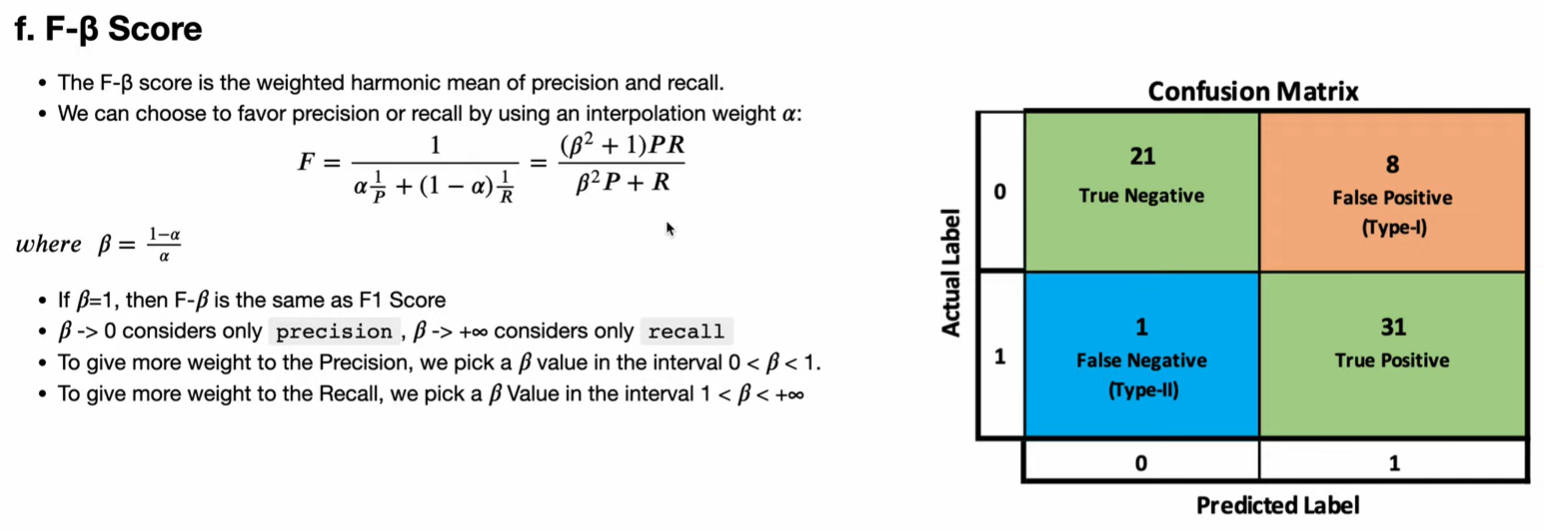

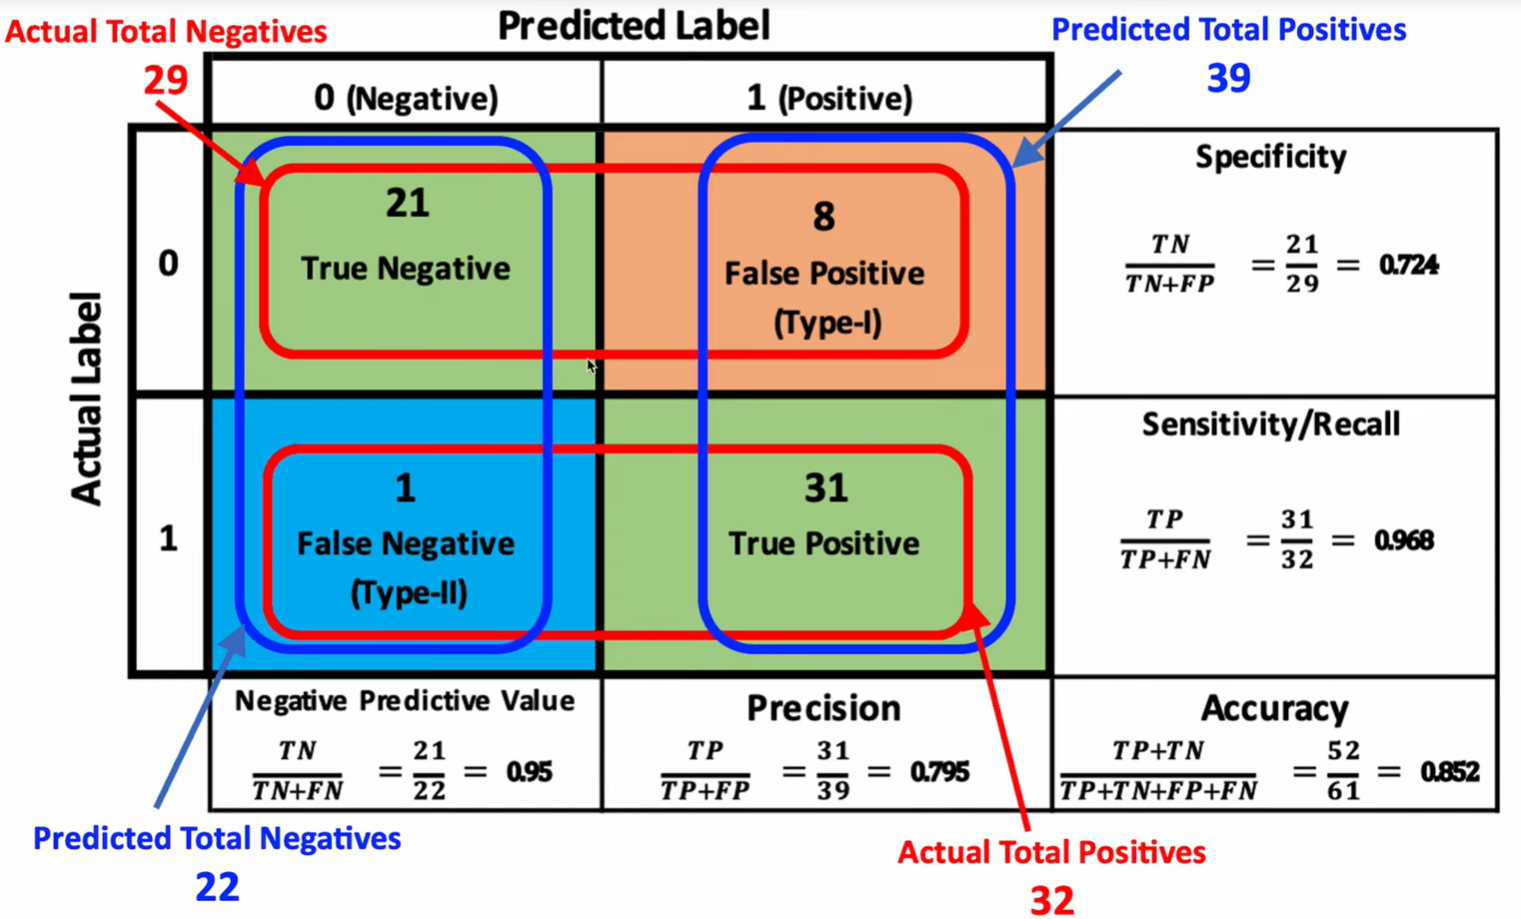

In [44]:
prob = lr.predict_proba(scaled_X_test)
prob

array([[0.27721767, 0.72278233],
       [0.18827362, 0.81172638],
       [0.22771789, 0.77228211],
       [0.48935794, 0.51064206],
       [0.37282473, 0.62717527],
       [0.13430871, 0.86569129],
       [0.04596103, 0.95403897],
       [0.00604359, 0.99395641],
       [0.71037236, 0.28962764],
       [0.46411729, 0.53588271],
       [0.95160819, 0.04839181],
       [0.98316949, 0.01683051],
       [0.2200984 , 0.7799016 ],
       [0.01542519, 0.98457481],
       [0.00510047, 0.99489953],
       [0.9293875 , 0.0706125 ],
       [0.96858822, 0.03141178],
       [0.34506237, 0.65493763],
       [0.00173938, 0.99826062],
       [0.91362877, 0.08637123],
       [0.19277299, 0.80722701],
       [0.94067249, 0.05932751],
       [0.00529859, 0.99470141],
       [0.9512936 , 0.0487064 ],
       [0.00589927, 0.99410073],
       [0.97518605, 0.02481395],
       [0.68049077, 0.31950923],
       [0.1378484 , 0.8621516 ],
       [0.14898082, 0.85101918],
       [0.49200924, 0.50799076],
       [0.

In [42]:
y_prob = prob[:,1]
y_prob

array([0.72278233, 0.81172638, 0.77228211, 0.51064206, 0.62717527,
       0.86569129, 0.95403897, 0.99395641, 0.28962764, 0.53588271,
       0.04839181, 0.01683051, 0.7799016 , 0.98457481, 0.99489953,
       0.0706125 , 0.03141178, 0.65493763, 0.99826062, 0.08637123,
       0.80722701, 0.05932751, 0.99470141, 0.0487064 , 0.99410073,
       0.02481395, 0.31950923, 0.8621516 , 0.85101918, 0.50799076,
       0.17942728, 0.63309508, 0.01544292, 0.40105584, 0.22447271,
       0.66334287, 0.97355878, 0.48408034, 0.98911291, 0.17993164,
       0.9811172 , 0.31821684, 0.8672472 , 0.05286828, 0.21257042,
       0.93246158, 0.0799378 , 0.12042907, 0.80936409, 0.81204118,
       0.21513325, 0.02246879, 0.01781547, 0.1878993 , 0.93563129,
       0.18659899, 0.03612217, 0.96882874, 0.89291792, 0.92022864,
       0.13599678])

**CM with the Defualt Threshod = 0.5 **

In [46]:
y_pred1 = np.array([1.0 if p > 0.5 else 0.0 for p in y_prob])
y_pred1

array([1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 0., 0., 1., 1., 1., 0., 0.,
       1., 1., 0., 1., 0., 1., 0., 1., 0., 0., 1., 1., 1., 0., 1., 0., 0.,
       0., 1., 1., 0., 1., 0., 1., 0., 1., 0., 0., 1., 0., 0., 1., 1., 0.,
       0., 0., 0., 1., 0., 0., 1., 1., 1., 0.])

Precision Score: 0.8787878787878788
Recall Score: 0.90625


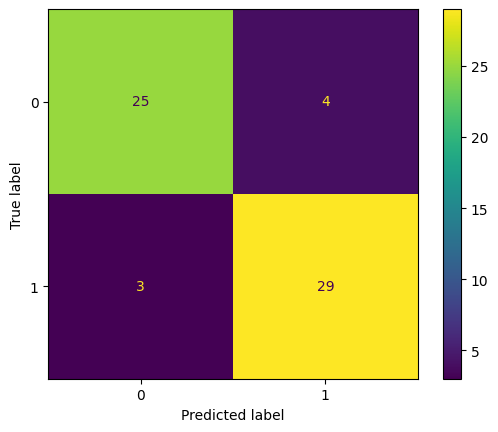

In [47]:
disp = ConfusionMatrixDisplay(confusion_matrix(y_test,y_pred=y_pred1))
disp.plot()

print("Precision Score:",precision_score(y_test, y_pred1))
print("Recall Score:",recall_score(y_test, y_pred1))


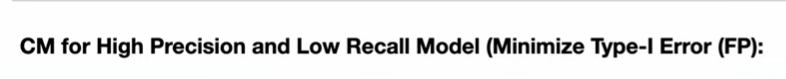

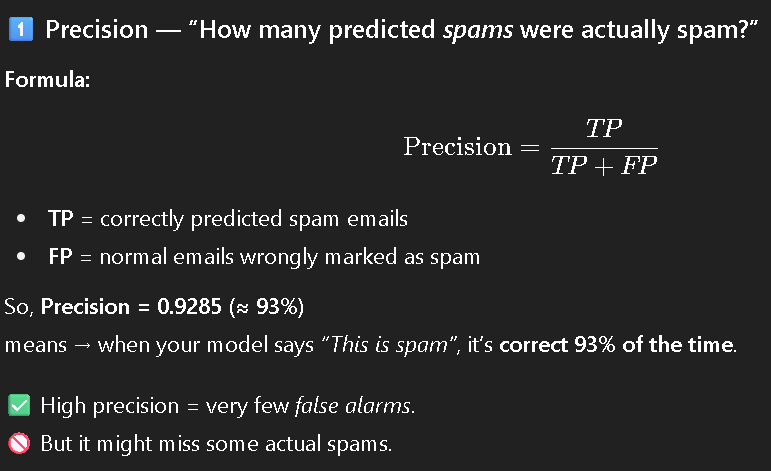

In [48]:
y_pred2 = np.array([1.0 if p > 0.9 else 0.0 for p in y_prob])
y_pred2

array([0., 0., 0., 0., 0., 0., 1., 1., 0., 0., 0., 0., 0., 1., 1., 0., 0.,
       0., 1., 0., 0., 0., 1., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 1., 0., 1., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
       0., 0., 0., 1., 0., 0., 1., 0., 1., 0.])

Precision Score: 0.9285714285714286
Recall Score: 0.40625


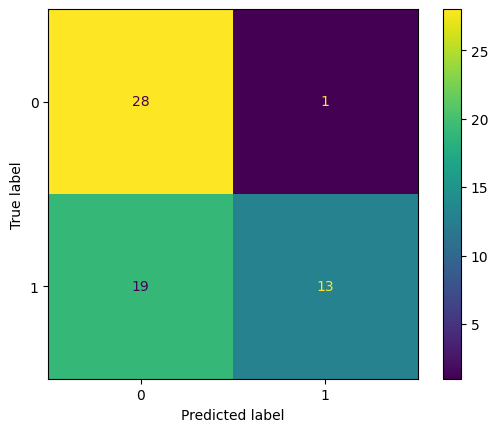

In [50]:
disp = ConfusionMatrixDisplay(confusion_matrix(y_test,y_pred=y_pred2))
disp.plot()

print("Precision Score:",precision_score(y_test, y_pred2))
print("Recall Score:",recall_score(y_test, y_pred2))


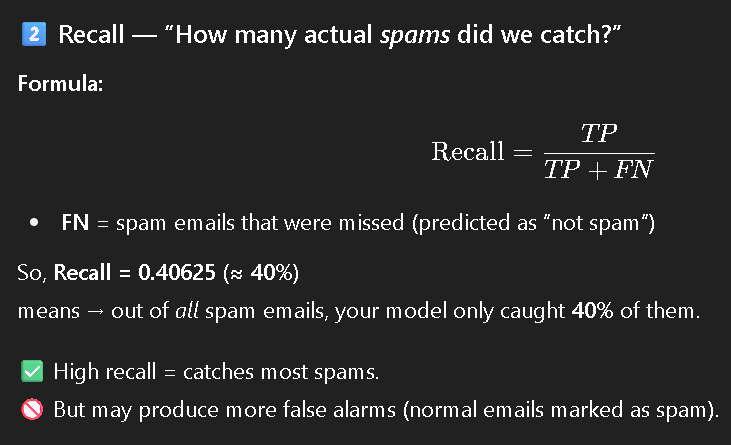

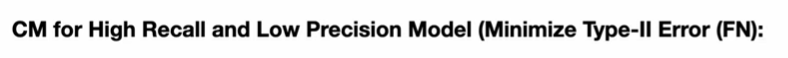

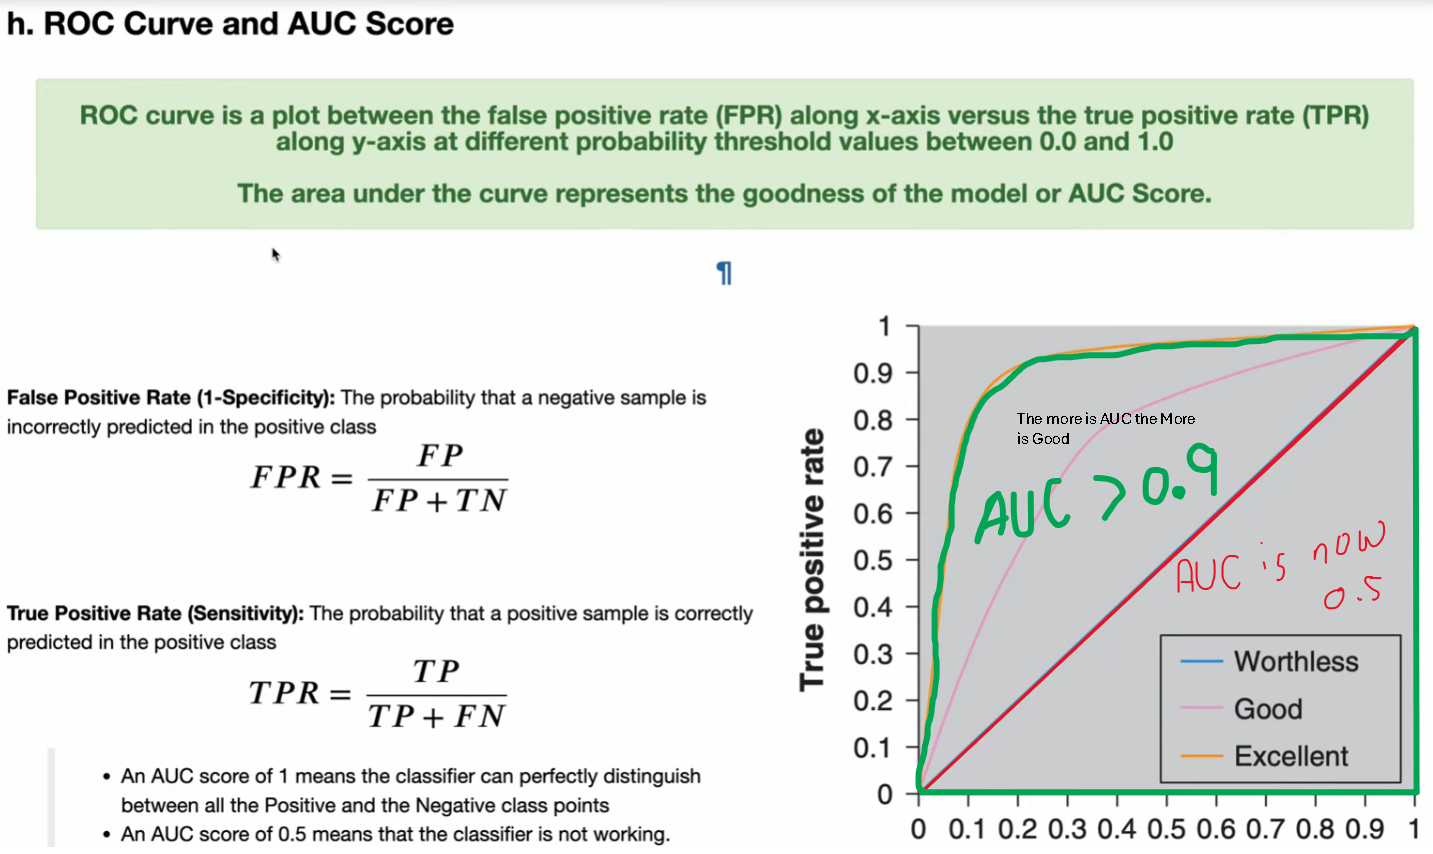

In [51]:
y_pred3 = np.array([1.0 if p > 0.2 else 0.0 for p in y_prob])
y_pred3

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 1., 1., 1., 0., 0.,
       1., 1., 0., 1., 0., 1., 0., 1., 0., 1., 1., 1., 1., 0., 1., 0., 1.,
       1., 1., 1., 1., 1., 0., 1., 1., 1., 0., 1., 1., 0., 0., 1., 1., 1.,
       0., 0., 0., 1., 0., 0., 1., 1., 1., 0.])

Precision Score: 0.7317073170731707
Recall Score: 0.9375


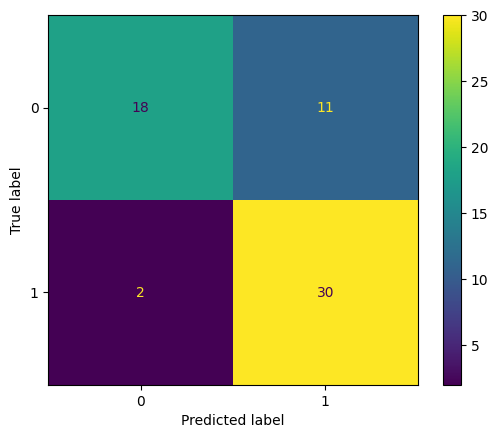

In [52]:
disp = ConfusionMatrixDisplay(confusion_matrix(y_test,y_pred=y_pred3))
disp.plot()

print("Precision Score:",precision_score(y_test, y_pred3))
print("Recall Score:",recall_score(y_test, y_pred3))


**AUC = Area Under Characteristic Curve**

**ROC = Reciver Operator Characteristic Curve**

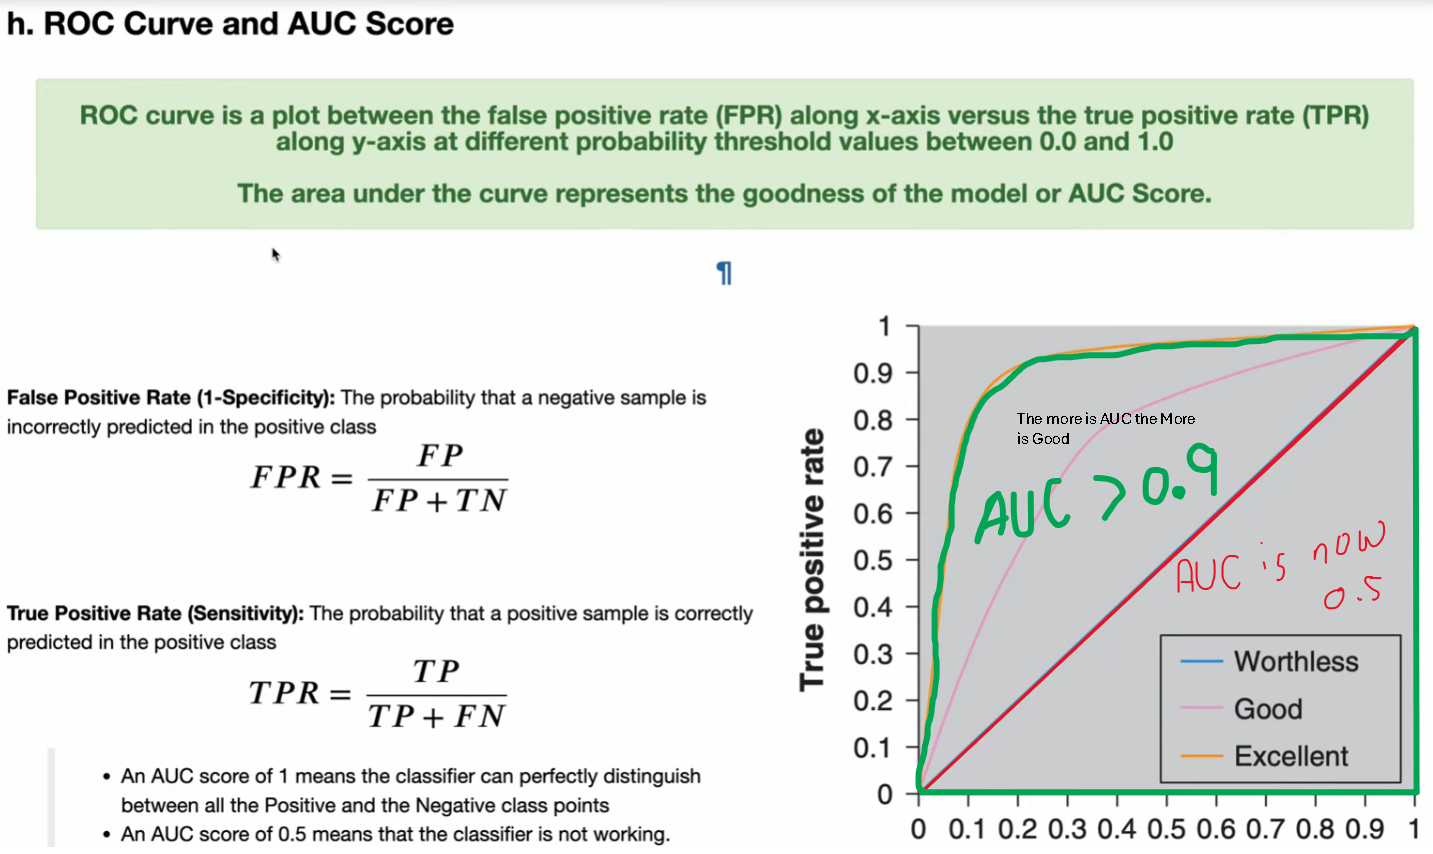

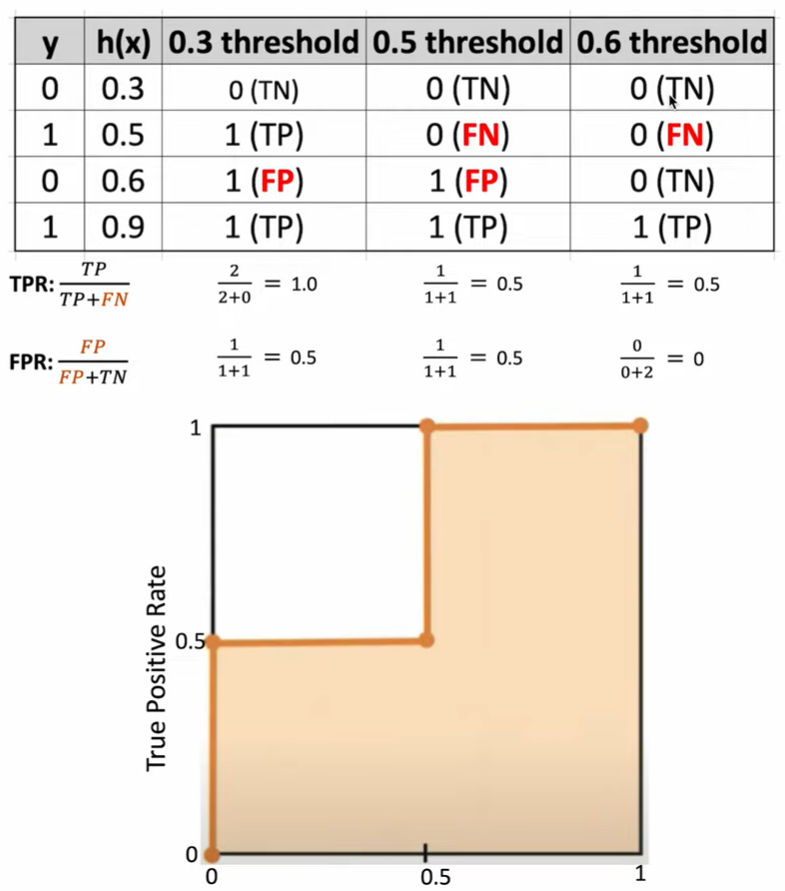

In [53]:
y_prob = lr.predict_proba(scaled_X_test)[:,1]
y_prob

array([0.72278233, 0.81172638, 0.77228211, 0.51064206, 0.62717527,
       0.86569129, 0.95403897, 0.99395641, 0.28962764, 0.53588271,
       0.04839181, 0.01683051, 0.7799016 , 0.98457481, 0.99489953,
       0.0706125 , 0.03141178, 0.65493763, 0.99826062, 0.08637123,
       0.80722701, 0.05932751, 0.99470141, 0.0487064 , 0.99410073,
       0.02481395, 0.31950923, 0.8621516 , 0.85101918, 0.50799076,
       0.17942728, 0.63309508, 0.01544292, 0.40105584, 0.22447271,
       0.66334287, 0.97355878, 0.48408034, 0.98911291, 0.17993164,
       0.9811172 , 0.31821684, 0.8672472 , 0.05286828, 0.21257042,
       0.93246158, 0.0799378 , 0.12042907, 0.80936409, 0.81204118,
       0.21513325, 0.02246879, 0.01781547, 0.1878993 , 0.93563129,
       0.18659899, 0.03612217, 0.96882874, 0.89291792, 0.92022864,
       0.13599678])

In [61]:
from sklearn.metrics import roc_curve
import pandas as pd

fpr, tpr, threshold =  roc_curve(y_test, y_prob)
df1 = pd.DataFrame(zip(threshold, fpr, tpr),columns=['Threshold', 'FPR', 'TPR'])
df1

,Threshold,FPR,TPR
0,inf,0.000000,0.00000
1,0.998261,0.000000,0.03125
2,0.984575,0.000000,0.21875
3,0.981117,0.034483,0.21875
4,0.809364,0.034483,0.65625
5,0.807227,0.068966,0.65625
6,0.772282,0.068966,0.71875
7,0.722782,0.103448,0.71875
8,0.627175,0.103448,0.84375
9,0.535883,0.137931,0.84375


In [62]:
df1 = df1.sort_values(by='Threshold', ascending=True)
df1

,Threshold,FPR,TPR
17,0.015443,1.000000,1.00000
16,0.135997,0.482759,1.00000
15,0.179427,0.482759,0.96875
14,0.179932,0.448276,0.96875
13,0.186599,0.448276,0.93750
12,0.289628,0.275862,0.93750
11,0.318217,0.275862,0.90625
10,0.507991,0.137931,0.90625
9,0.535883,0.137931,0.84375
8,0.627175,0.103448,0.84375


In [63]:
from sklearn.metrics import roc_auc_score

model_auc = roc_auc_score(y_test, y_prob)
print('AUC Score: ',model_auc)

AUC Score:  0.9213362068965517


In [66]:
print(fpr,'\n\n\n',tpr)

[0.         0.         0.         0.03448276 0.03448276 0.06896552
 0.06896552 0.10344828 0.10344828 0.13793103 0.13793103 0.27586207
 0.27586207 0.44827586 0.44827586 0.48275862 0.48275862 1.        ] 


 [0.      0.03125 0.21875 0.21875 0.65625 0.65625 0.71875 0.71875 0.84375
 0.84375 0.90625 0.90625 0.9375  0.9375  0.96875 0.96875 1.      1.     ]


In [67]:
df1

,Threshold,FPR,TPR
17,0.015443,1.000000,1.00000
16,0.135997,0.482759,1.00000
15,0.179427,0.482759,0.96875
14,0.179932,0.448276,0.96875
13,0.186599,0.448276,0.93750
12,0.289628,0.275862,0.93750
11,0.318217,0.275862,0.90625
10,0.507991,0.137931,0.90625
9,0.535883,0.137931,0.84375
8,0.627175,0.103448,0.84375


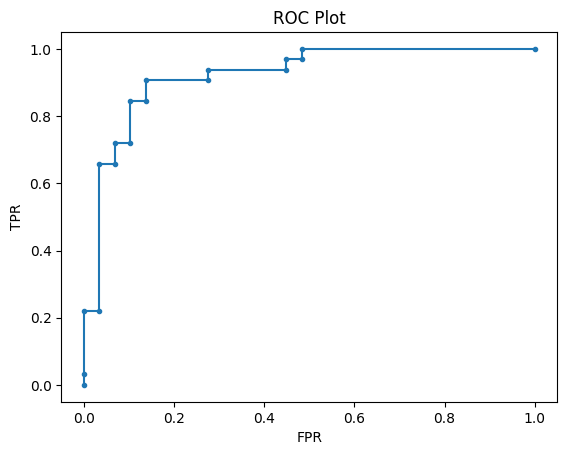

In [64]:
import matplotlib.pyplot as plt
plt.plot(fpr, tpr, marker='.')
plt.title('ROC Plot')
plt.xlabel("FPR")
plt.ylabel('TPR')
plt.show()

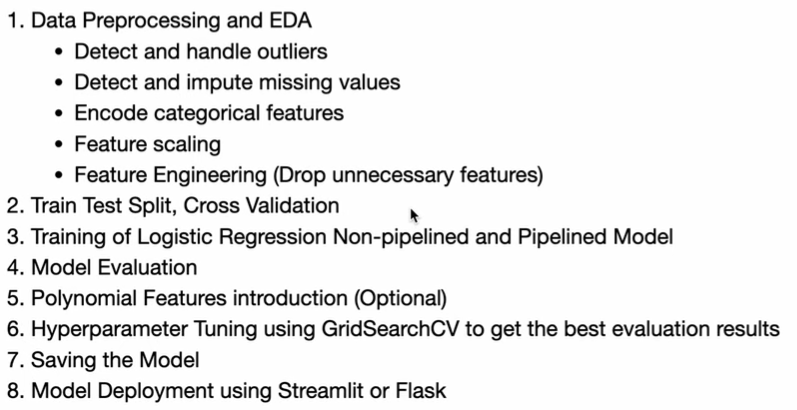

In [69]:
import numpy as np # np is short for numpy
import pandas as pd # pandas is so commonly used, it's shortened to pd
import matplotlib.pyplot as plt
import seaborn as sns # seaborn gets shortened to sns

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.datasets import fetch_openml
titanic = fetch_openml(name='titanic', version=1, as_frame=True)
df = pd.DataFrame(titanic.data, columns=titanic.feature_names)
df['target'] = titanic.target
df

,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest,target
0,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO",1
1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON",1
2,1,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON",0
3,1,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON",0
4,1,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON",0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3,"Zabour, Miss. Hileni",female,14.5000,1,0,2665,14.4542,NaN,C,NaN,328.0,NaN,0
1305,3,"Zabour, Miss. Thamine",female,NaN,1,0,2665,14.4542,NaN,C,NaN,NaN,NaN,0
1306,3,"Zakarian, Mr. Mapriededer",male,26.5000,0,0,2656,7.2250,NaN,C,NaN,304.0,NaN,0
1307,3,"Zakarian, Mr. Ortin",male,27.0000,0,0,2670,7.2250,NaN,C,NaN,NaN,NaN,0
